In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/legal_cleaned.csv")

print(df.shape)

(24809, 5)


In [3]:
import langchain

print(langchain.__version__)

1.3.1


In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len
)

print("Splitter Created")

c:\Users\tanis\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Splitter Created


In [5]:
sample_text = df.iloc[0]["case_text"]

chunks = splitter.split_text(sample_text)

print("Number of Chunks:", len(chunks))

Number of Chunks: 1


In [6]:
for i, chunk in enumerate(chunks[:3]):
    print(f"\n----- CHUNK {i+1} -----\n")
    print(chunk[:500])


----- CHUNK 1 -----

Ordinarily that discretion will be exercised so that costs follow the event and are awarded on a party and party basis. A departure from normal practice to award indemnity costs requires some special or unusual feature in the case: Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Ltd (No 2) [2002] FCA 224 ; (2002) 190 ALR 121 at [11] (Weinberg J) citing Colgate Palmolive Co v Cussons Pty Ltd (1993) 46 FCR 225 at 233 (Sheppard J).


In [7]:
df["text_length"] = df["case_text"].astype(str).apply(len)

longest_doc_idx = df["text_length"].idxmax()

print("Index:", longest_doc_idx)
print("Length:", df.loc[longest_doc_idx, "text_length"])

Index: 14429
Length: 133561


In [8]:
long_text = df.loc[longest_doc_idx, "case_text"]

long_chunks = splitter.split_text(long_text)

print("Number of Chunks:", len(long_chunks))

Number of Chunks: 167


In [9]:
print("First Chunk Length:", len(long_chunks[0]))
print("Second Chunk Length:", len(long_chunks[1]))

First Chunk Length: 997
Second Chunk Length: 996


In [10]:
all_chunks = []

for idx, row in df.iterrows():

    text = row["case_text"]

    chunks = splitter.split_text(text)

    for i, chunk in enumerate(chunks):

        all_chunks.append({
            "case_id": row["case_id"],
            "case_outcome": row["case_outcome"],
            "chunk_id": f"{row['case_id']}_{i}",
            "chunk_text": chunk
        })

print("Total Chunks:", len(all_chunks))

Total Chunks: 88437


In [11]:
chunks_df = pd.DataFrame(all_chunks)

print(chunks_df.shape)

chunks_df.head()

(88437, 4)


,case_id,case_outcome,chunk_id,chunk_text
0,Case1,cited,Case1_0,Ordinarily that discretion will be exercised s...
1,Case2,cited,Case2_0,The general principles governing the exercise ...
2,Case3,cited,Case3_0,Ordinarily that discretion will be exercised s...
3,Case4,cited,Case4_0,The general principles governing the exercise ...
4,Case5,cited,Case5_0,The preceding general principles inform the ex...


In [12]:
chunks_df.to_csv(
    "../data/processed/legal_chunks.csv",
    index=False
)

print("Chunks Saved Successfully")

Chunks Saved Successfully


In [13]:
chunks_df["chunk_length"] = chunks_df["chunk_text"].apply(len)

print(chunks_df["chunk_length"].describe())

count    88437.000000
mean       884.566822
std        215.059445
min         95.000000
25%        904.000000
50%        995.000000
75%        998.000000
max       1000.000000
Name: chunk_length, dtype: float64


In [17]:
print("Min Length :", chunks_df["chunk_length"].min())
print("Max Length :", chunks_df["chunk_length"].max())
print("Mean Length:", chunks_df["chunk_length"].mean())

Min Length : 95
Max Length : 1000
Mean Length: 884.5668215792033


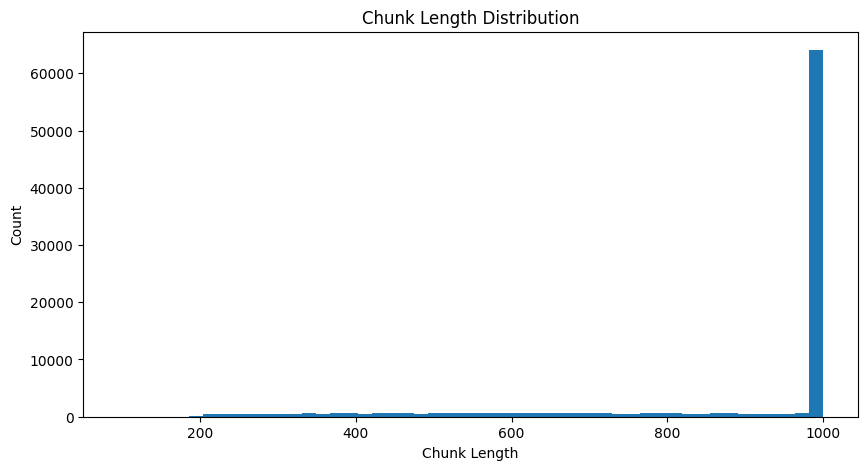

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(chunks_df["chunk_length"], bins=50)

plt.title("Chunk Length Distribution")
plt.xlabel("Chunk Length")
plt.ylabel("Count")

plt.show()